<a href="https://colab.research.google.com/github/th900/Ciencia-de-dados-para-o-agronegocio/blob/main/Ci%C3%AAncia_de_dados_para_agronegocio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import warnings
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

warnings.filterwarnings("ignore")

In [3]:
RAW_PATH = "https://raw.githubusercontent.com/th900/Ciencia-de-dados-para-o-agronegocio/refs/heads/main/treino.csv"

df = pd.read_csv(RAW_PATH)
print("=" * 60)
print("1. DATASET CARREGADO")
print(f"   Shape: {df.shape}")
print("=" * 60)

1. DATASET CARREGADO
   Shape: (88858, 10)


In [4]:
df.head(10)

,ID,Estimated_Insects_Count,Crop_Type,Soil_Type,Pesticide_Use_Category,Number_Doses_Week,Number_Weeks_Used,Number_Weeks_Quit,Season,Crop_Damage
0,F00000001,188,1,0,1,0,0.0,0,1,0
1,F00000003,209,1,0,1,0,0.0,0,2,1
2,F00000004,257,1,0,1,0,0.0,0,2,1
3,F00000005,257,1,1,1,0,0.0,0,2,1
4,F00000006,342,1,0,1,0,0.0,0,2,1
5,F00000008,448,0,1,1,0,NaN,0,2,1
6,F00000009,448,0,1,1,0,NaN,0,2,1
7,F00000010,577,1,0,1,0,0.0,0,1,2
8,F00000012,731,0,0,1,0,0.0,0,2,0
9,F00000020,1132,1,0,1,0,0.0,0,1,2


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88858 entries, 0 to 88857
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       88858 non-null  object 
 1   Estimated_Insects_Count  88858 non-null  int64  
 2   Crop_Type                88858 non-null  int64  
 3   Soil_Type                88858 non-null  int64  
 4   Pesticide_Use_Category   88858 non-null  int64  
 5   Number_Doses_Week        88858 non-null  int64  
 6   Number_Weeks_Used        79858 non-null  float64
 7   Number_Weeks_Quit        88858 non-null  int64  
 8   Season                   88858 non-null  int64  
 9   Crop_Damage              88858 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 6.8+ MB


In [6]:
df["Crop_Damage"].value_counts()

,count
Crop_Damage,
0,74238
1,12307
2,2313


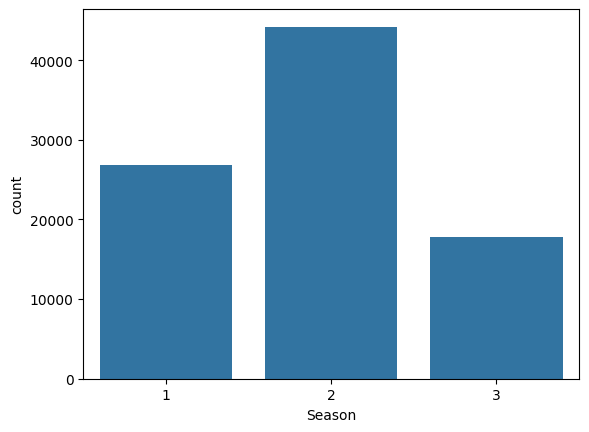

In [7]:
df['Season'].value_counts()
ax = sns.countplot(x=df['Season'])

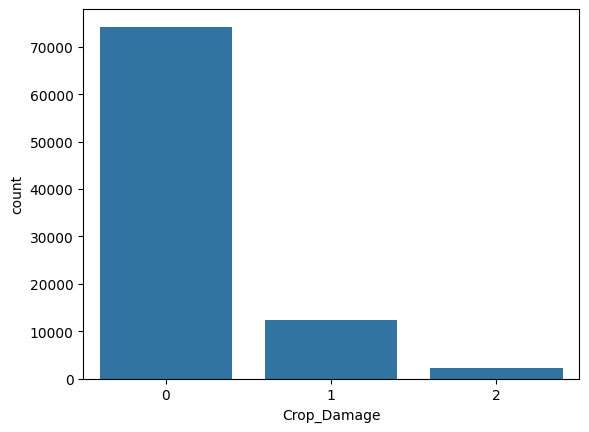

In [8]:
df['Crop_Damage'].value_counts()
ax = sns.countplot(x = df['Crop_Damage'])

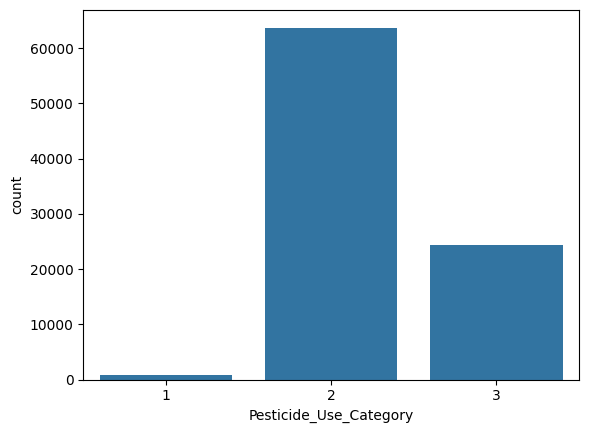

In [9]:
df['Pesticide_Use_Category'].value_counts()
ax = sns.countplot(x = df['Pesticide_Use_Category'])

In [10]:
df.isnull().sum()

,0
ID,0
Estimated_Insects_Count,0
Crop_Type,0
Soil_Type,0
Pesticide_Use_Category,0
Number_Doses_Week,0
Number_Weeks_Used,9000
Number_Weeks_Quit,0
Season,0
Crop_Damage,0


In [11]:
df.duplicated().sum()

np.int64(0)

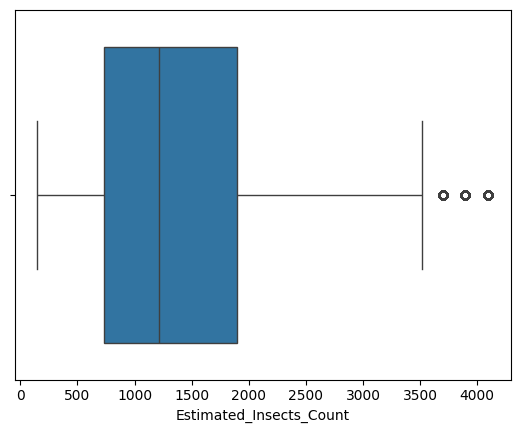

In [12]:
df['Estimated_Insects_Count'].describe()
ax= sns.boxplot( x = df['Estimated_Insects_Count'])

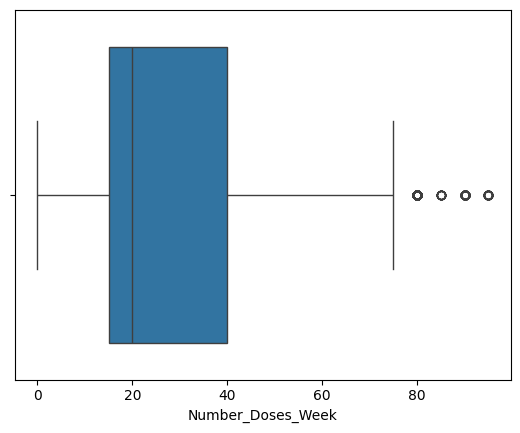

In [13]:
df['Number_Doses_Week'].describe()
ax = sns.boxplot(x = df['Number_Doses_Week'])

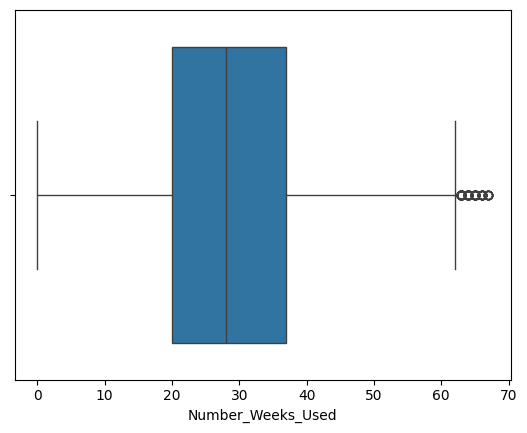

In [14]:
df['Number_Weeks_Used'].describe()
ax = sns.boxplot(x = df['Number_Weeks_Used'])

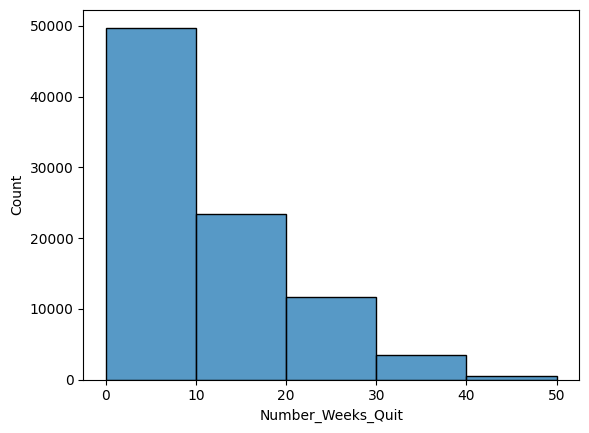

In [15]:
df['Number_Weeks_Quit'].describe()
ax = sns.histplot(x = df['Number_Weeks_Quit'], bins = 5)

In [16]:
df.dropna(inplace=True)

In [18]:
for col in ['Crop_Type', 'Soil_Type', 'Pesticide_Use_Category', 'Season']:
  df = pd.get_dummies(df, columns = [col])

In [19]:
df.drop(columns=["ID"], axis = 1, inplace=True)

In [20]:
df.head(4)

,Estimated_Insects_Count,Number_Doses_Week,Number_Weeks_Used,Number_Weeks_Quit,Crop_Damage,Crop_Type_0,Crop_Type_1,Soil_Type_0,Soil_Type_1,Pesticide_Use_Category_1,Pesticide_Use_Category_2,Pesticide_Use_Category_3,Season_1,Season_2,Season_3
0,188,0,0.0,0,0,False,True,True,False,True,False,False,True,False,False
1,209,0,0.0,0,1,False,True,True,False,True,False,False,False,True,False
2,257,0,0.0,0,1,False,True,True,False,True,False,False,False,True,False
3,257,0,0.0,0,1,False,True,False,True,True,False,False,False,True,False


In [21]:
X = df.drop(['Crop_Damage'], axis = 1)
y = df['Crop_Damage']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [22]:


def report_metricas(y_test, y_pred):
    """
    Exibe as principais métricas de classificação para o dano da lavoura.
    """
    # Calculando as métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"--- Relatório de Performance ---")
    print(f"Acurácia:  {acc:.2%}")
    print(f"Precisão:  {prec:.2%}")
    print(f"Recall:    {rec:.2%}")
    print(f"F1-Score:  {f1:.2%}")
    print("-" * 30)
    '''  Matriz de Confusão para ver onde o modelo está errando (ex: trocando dano por praga por dano natural)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de Confusão')
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.show()
    '''

In [23]:
models_name = {
    "Regressão logistica": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
}

for name, model in models_name.items():
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  print(f"--- {name} ---")
  report_metricas(y_test, y_pred)

--- Regressão logistica ---
--- Relatório de Performance ---
Acurácia:  83.23%
Precisão:  75.93%
Recall:    83.23%
F1-Score:  77.75%
------------------------------
--- Random Forest ---
--- Relatório de Performance ---
Acurácia:  82.62%
Precisão:  78.77%
Recall:    82.62%
F1-Score:  80.16%
------------------------------
--- Decision Tree ---
--- Relatório de Performance ---
Acurácia:  75.09%
Precisão:  76.48%
Recall:    75.09%
F1-Score:  75.75%
------------------------------
--- KNN ---
--- Relatório de Performance ---
Acurácia:  82.63%
Precisão:  77.91%
Recall:    82.63%
F1-Score:  79.63%
------------------------------
--- Gradient Boosting ---
--- Relatório de Performance ---
Acurácia:  84.76%
Precisão:  79.45%
Recall:    84.76%
F1-Score:  80.36%
------------------------------


In [28]:
model = CatBoostClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)



Learning rate set to 0.097814
0:	learn: 0.9815173	total: 69.4ms	remaining: 1m 9s
1:	learn: 0.8935871	total: 115ms	remaining: 57.2s
2:	learn: 0.8232068	total: 162ms	remaining: 53.9s
3:	learn: 0.7658542	total: 220ms	remaining: 54.7s
4:	learn: 0.7190927	total: 268ms	remaining: 53.3s
5:	learn: 0.6801215	total: 324ms	remaining: 53.7s
6:	learn: 0.6471752	total: 396ms	remaining: 56.1s
7:	learn: 0.6187689	total: 448ms	remaining: 55.6s
8:	learn: 0.5943440	total: 496ms	remaining: 54.6s
9:	learn: 0.5737940	total: 541ms	remaining: 53.5s
10:	learn: 0.5561769	total: 587ms	remaining: 52.8s
11:	learn: 0.5406725	total: 636ms	remaining: 52.3s
12:	learn: 0.5270666	total: 688ms	remaining: 52.2s
13:	learn: 0.5152408	total: 734ms	remaining: 51.7s
14:	learn: 0.5049730	total: 779ms	remaining: 51.1s
15:	learn: 0.4958861	total: 829ms	remaining: 51s
16:	learn: 0.4879409	total: 886ms	remaining: 51.2s
17:	learn: 0.4807684	total: 947ms	remaining: 51.7s
18:	learn: 0.4748812	total: 993ms	remaining: 51.3s
19:	learn: 0

Cat Boost apresentou bons resultados, junto com o gradiente boost

In [29]:
report_metricas(y_test, y_pred)

--- Relatório de Performance ---
Acurácia:  85.03%
Precisão:  81.03%
Recall:    85.03%
F1-Score:  81.48%
------------------------------


In [31]:
report_metricas(y_test, y_pred)

--- Relatório de Performance ---
Acurácia:  85.03%
Precisão:  81.03%
Recall:    85.03%
F1-Score:  81.48%
------------------------------
